# Definir a Arquitetura LeNet-5 com PyTorch

Implemente a classe LeNet5 herdando de nn.Module, declarando as camadas conforme a arquitetura original (duas convolucionais, pooling, três lineares, funções de ativação).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):

    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # C1: Convolution (1 input channel, 6 output channels, 5x5 kernel)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        # S2: Max Pooling (2x2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C3: Convolution (6 → 16 feature maps)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        # S4: Max Pooling (2x2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C5: Convolution (16 → 120 feature maps)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5)
        # F6: Fully Connected (120 → 84)
        self.fc1 = nn.Linear(120, 84)
        # Output layer (84 → number of classes)
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        # C1 → ReLU → S2
        x = self.pool1(F.relu(self.conv1(x)))
        # C3 → ReLU → S4
        x = self.pool2(F.relu(self.conv2(x)))
        # C5 → ReLU
        x = F.relu(self.conv3(x))
        # Flatten
        x = torch.flatten(x, 1)
        # F6 → ReLU
        x = F.relu(self.fc1(x))
        # Output
        x = self.fc2(x)
        return x

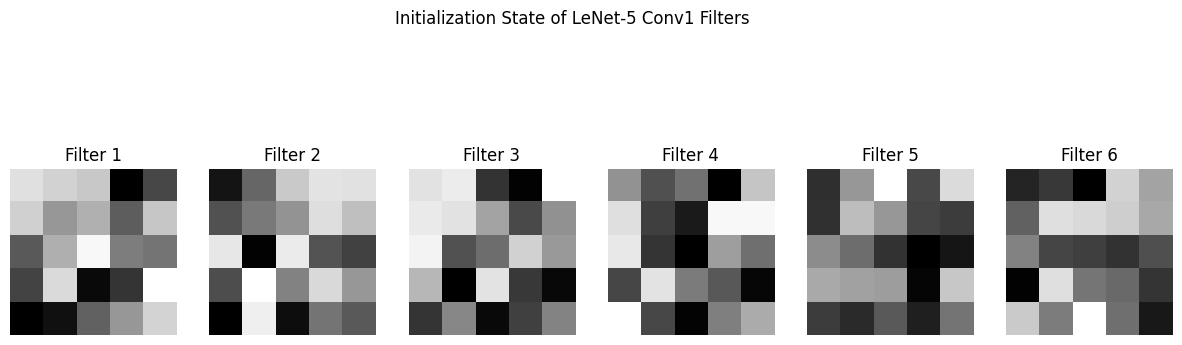

In [3]:
import matplotlib.pyplot as plt

# Visualizar graficamente os filtros iniciais da primeira camada convolucional
model = LeNet5(num_classes=10)
filters = model.conv1.weight.detach()

fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(filters[i, 0], cmap='gray')
    ax.set_title(f'Filter {i + 1}')
    ax.axis('off')

plt.suptitle('Initialization State of LeNet-5 Conv1 Filters')
plt.show()

Visualizing feature maps for digit: 4


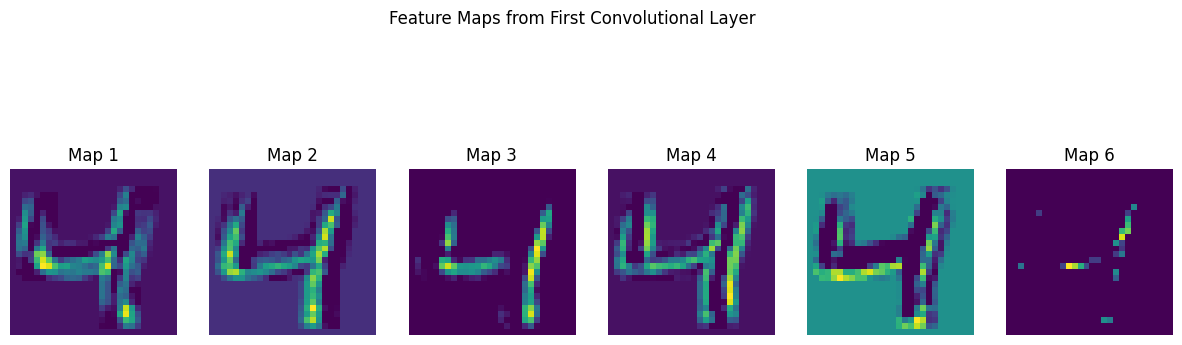

In [6]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Pad(2),  # MNIST is 28x28; LeNet-5 expects 32x32
    transforms.ToTensor(),
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Get a single sample image from the dataset
sample_image, sample_label = train_dataset[2]

# Add batch dimension
sample_image = sample_image.unsqueeze(0)

# Set model to evaluation mode and disable gradients
model.eval()
with torch.no_grad():
    # Move to device
    sample_image = sample_image.to(device)
    
    # Pass through first conv layer and apply ReLU
    feature_maps = F.relu(model.conv1(sample_image))

# Move back to CPU for plotting
feature_maps = feature_maps.cpu().squeeze(0)

# Print the digit being visualized
print(f"Visualizing feature maps for digit: {sample_label}")

# Create the plot
fig, axes = plt.subplots(1, 6, figsize=(15, 5))

# Loop to show images
for i in range(6):
    axes[i].imshow(feature_maps[i], cmap='viridis')
    axes[i].set_title(f'Map {i+1}')
    axes[i].axis('off')

# Add suptitle and show
plt.suptitle('Feature Maps from First Convolutional Layer')
plt.show()

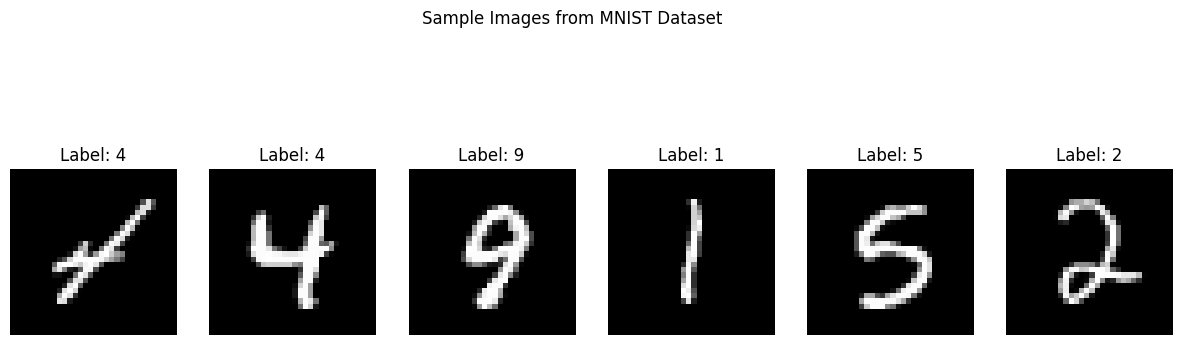

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.Pad(2),  # MNIST is 28x28; LeNet-5 expects 32x32
    transforms.ToTensor(),
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)
dataiter = iter(train_loader)
images, labels = next(dataiter)
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')
plt.suptitle('Sample Images from MNIST Dataset')
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

#Hyperparameters
learning_rate = 0.001 #Velocidade de aprendizado
batch_size = 64 #Número de amostras processadas antes de atualizar os pesos do modelo
num_epochs = 5 #Número de vezes que o modelo passará por todo o conjunto de dados durante o treinamento


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

criterion = nn.CrossEntropyLoss() #Função de perda para classificação multi-classe
optimizer = optim.Adam(model.parameters(), lr=learning_rate) 
#Algoritmo de otimização para atualizar os pesos do modelo com base na função de perda


print(f'Training on {device}...')
model.train()

for epoch in range(num_epochs): #Itera sobre o número de épocas
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader): # Itera sobre os batches de dados
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels) #Erro de classificação entre as previsões do modelo e os rótulos reais

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

print("Training finished!")

Training on cpu...
Epoch [1/5], Step [100/938], Loss: 0.3810
Epoch [1/5], Step [200/938], Loss: 0.2720
Epoch [1/5], Step [300/938], Loss: 0.2453
Epoch [1/5], Step [400/938], Loss: 0.2331
Epoch [1/5], Step [500/938], Loss: 0.2092
Epoch [1/5], Step [600/938], Loss: 0.1637
Epoch [1/5], Step [700/938], Loss: 0.2770
Epoch [1/5], Step [800/938], Loss: 0.3031
Epoch [1/5], Step [900/938], Loss: 0.0811
Epoch [2/5], Step [100/938], Loss: 0.1334
Epoch [2/5], Step [200/938], Loss: 0.0515
Epoch [2/5], Step [300/938], Loss: 0.0934
Epoch [2/5], Step [400/938], Loss: 0.0629
Epoch [2/5], Step [500/938], Loss: 0.1751
Epoch [2/5], Step [600/938], Loss: 0.0091
Epoch [2/5], Step [700/938], Loss: 0.0329
Epoch [2/5], Step [800/938], Loss: 0.0358
Epoch [2/5], Step [900/938], Loss: 0.0222
Epoch [3/5], Step [100/938], Loss: 0.1473
Epoch [3/5], Step [200/938], Loss: 0.0337
Epoch [3/5], Step [300/938], Loss: 0.0334
Epoch [3/5], Step [400/938], Loss: 0.0699
Epoch [3/5], Step [500/938], Loss: 0.0964
Epoch [3/5], St

In [9]:
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the network on the 10,000 test images: {accuracy:.2f}%')

Accuracy of the network on the 10,000 test images: 98.78%


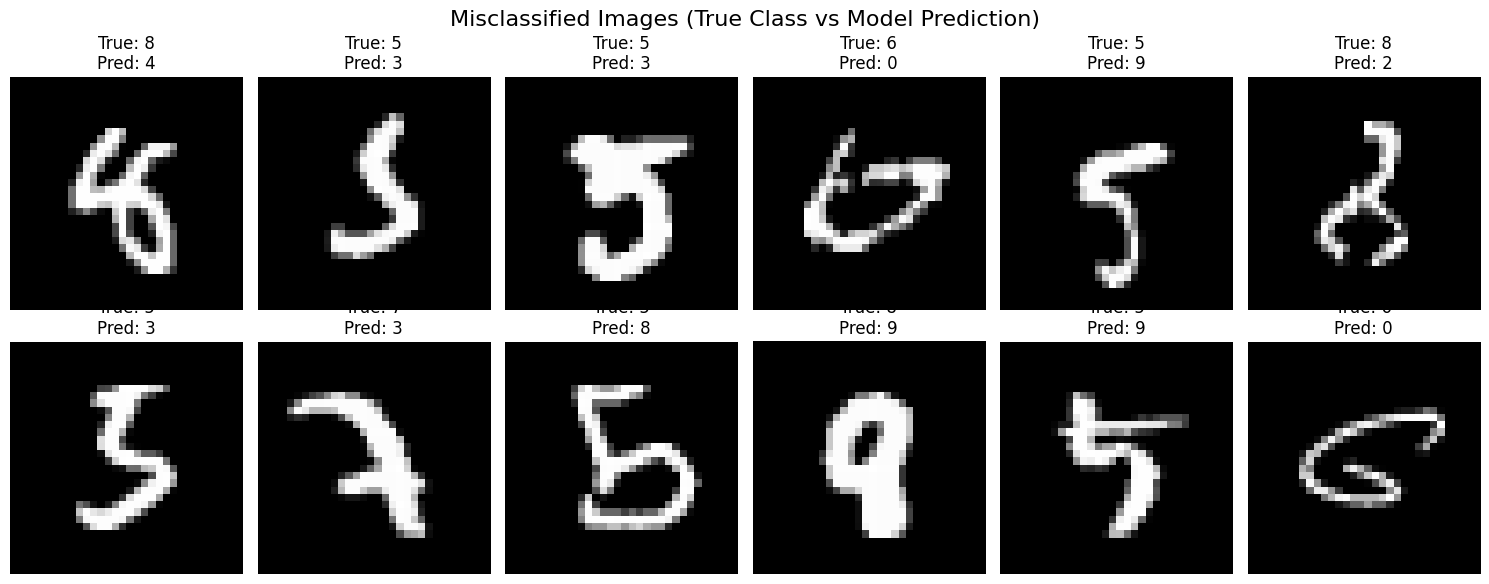

In [10]:
misclassified_images = []
misclassified_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        mask = predicted != labels
        if mask.any():
            misclassified_images.append(images[mask].cpu())
            misclassified_labels.append(labels[mask].cpu())
            predicted_labels.append(predicted[mask].cpu())

if len(misclassified_images) > 0:
    misclassified_images = torch.cat(misclassified_images)
    misclassified_labels = torch.cat(misclassified_labels)
    predicted_labels = torch.cat(predicted_labels)
else:
    misclassified_images = torch.empty((0, 1, 32, 32))
    misclassified_labels = torch.empty((0,), dtype=torch.long)
    predicted_labels = torch.empty((0,), dtype=torch.long)

num_to_show = min(12, len(misclassified_images))

fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for i in range(num_to_show):
    ax = axes[i // 6, i % 6]
    ax.imshow(misclassified_images[i].squeeze(), cmap='gray')
    ax.set_title(f'True: {misclassified_labels[i].item()}\nPred: {predicted_labels[i].item()}')
    ax.axis('off')

plt.suptitle('Misclassified Images (True Class vs Model Prediction)', fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
import os

# Create 'weights' directory if it doesn't exist
os.makedirs('weights', exist_ok=True)

# Set save path
PATH = './weights/lenet5_mnist.pth'

torch.save(model.state_dict(), PATH)
print(f"Model saved to {PATH}")

Model saved to ./weights/lenet5_mnist.pth


In [12]:
# 1. Create a new instance of the model
model = LeNet5(num_classes=10)

# 2. Load the state dictionary
model.load_state_dict(torch.load('./weights/lenet5_mnist.pth'))

# 3. Set to evaluation mode if you're using it for inference
model.eval()

print("New model instance created and weights loaded successfully!")

New model instance created and weights loaded successfully!
